# Insurance Claim Fraud Detection – Classification

## Problem Statement

The objective of this project is to develop a machine learning classification
system that predicts whether an insurance claim is fraudulent or legitimate.

The target variable is `fraud_reported`, where:
- `Y` represents a reported fraud
- `N` represents a non-fraudulent claim

## Importing Required Libraries

In [149]:
# Data handling
import pandas as pd     # Pandas is used for loading and analysing the dataset.
import numpy as np      # NumPy provides numerical operations.

# Visualisation
# Matplotlib and Seaborn are used for EDA visualisations.
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
# Scikit-learn provides preprocessing and train/test splitting tools.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Display settings
pd.set_option("display.max_columns", None)

# Reproducibility
RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

## Section A - Dataset & EDA
### Dataset Loading & Audit

In [150]:
# Load the Dataset
# Inspect it's Size & Structure

df = pd.read_csv("C:/Users/Tejhu/23CSE301-ML-Capstone-1/data/insurance_claims.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1000, 40)


In [151]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [152]:
df.tail()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,FEMALE,Masters,craft-repair,paintball,unmarried,0,0,2015-02-22,Single Vehicle Collision,Front Collision,Minor Damage,Fire,NC,Northbrook,6045 Andromedia St,20,1,YES,0,1,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,FEMALE,PhD,prof-specialty,sleeping,wife,70900,0,2015-01-24,Single Vehicle Collision,Rear Collision,Major Damage,Fire,SC,Northbend,3092 Texas Drive,23,1,YES,2,3,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,FEMALE,Masters,armed-forces,bungie-jumping,other-relative,35100,0,2015-01-23,Multi-vehicle Collision,Side Collision,Minor Damage,Police,NC,Arlington,7629 5th St,4,3,?,2,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,MALE,Associate,handlers-cleaners,base-jumping,wife,0,0,2015-02-26,Single Vehicle Collision,Rear Collision,Major Damage,Other,NY,Arlington,6128 Elm Lane,2,1,?,0,1,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,FEMALE,Associate,sales,kayaking,husband,0,0,2015-02-26,Parked Car,?,Minor Damage,Police,WV,Columbus,1416 Cherokee Ridge,6,1,?,0,3,?,5060,460,920,3680,Mercedes,E400,2007,N,NaN


In [153]:
# A random sample is also viewed to ensure that the observations do not depend only on their position in the dataset.

df.sample(5, random_state=RANDOM_STATE)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
521,5,26,924318,2014-07-27,IL,250/500,2000,1137.02,0,468872,FEMALE,PhD,farming-fishing,skydiving,not-in-family,31500,0,2015-01-25,Single Vehicle Collision,Rear Collision,Total Loss,Ambulance,WV,Springfield,3706 Texas Hwy,22,1,YES,1,3,?,88110,16020,16020,56070,Audi,A5,2003,N,NaN
737,160,33,180286,2009-02-08,IL,500/1000,1000,1422.78,0,616583,FEMALE,High School,exec-managerial,exercise,husband,61600,0,2015-01-20,Multi-vehicle Collision,Front Collision,Total Loss,Ambulance,NC,Riverwood,1989 Solo Lane,17,3,?,2,3,YES,52800,5280,5280,42240,Nissan,Pathfinder,2006,N,NaN
740,385,51,178081,1990-07-20,IN,250/500,1000,976.37,0,602842,FEMALE,MD,craft-repair,reading,husband,0,-61000,2015-02-18,Multi-vehicle Collision,Rear Collision,Minor Damage,Other,WV,Riverwood,1422 Flute Ave,14,3,?,1,3,?,67600,13520,6760,47320,Suburu,Legacy,2007,N,NaN
660,446,57,991480,1992-12-09,IN,100/300,2000,1373.21,0,478486,MALE,College,adm-clerical,sleeping,unmarried,42700,-64900,2015-02-14,Multi-vehicle Collision,Front Collision,Total Loss,Police,SC,Northbrook,9734 2nd Ridge,10,3,NO,0,0,NO,62800,6280,12560,43960,Jeep,Wrangler,2012,N,NaN
411,84,29,630998,2003-04-09,OH,250/500,1000,1117.17,0,473645,FEMALE,High School,machine-op-inspct,video-games,not-in-family,0,-29900,2015-02-12,Parked Car,?,Trivial Damage,Police,SC,Arlington,3693 Pine Ave,6,1,YES,2,0,YES,6820,620,1240,4960,BMW,3 Series,2005,N,NaN


### Data Types

The dataset contains both numerical and categorical variables.

Numerical variables include attributes such as age, months as a customer,
premium, claim amounts, number of vehicles, and vehicle year.

Categorical variables include attributes such as policy state, occupation,
incident type, incident severity, and fraud status.

In [154]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

Number of rows: 1000
Number of columns: 40

Data types:


,dtype
months_as_customer,int64
age,int64
policy_number,int64
policy_bind_date,str
policy_state,str
policy_csl,str
policy_deductable,int64
policy_annual_premium,float64
umbrella_limit,int64
insured_zip,int64


In [155]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   str    
 4   policy_state                 1000 non-null   str    
 5   policy_csl                   1000 non-null   str    
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   str    
 11  insured_education_level      1000 non-null   str    
 12  insured_occupation           1000 non-null   str    
 13  insured_hobbies              1

### Missing Values

Missing values are checked before modelling because machine learning
algorithms generally cannot directly work with missing data.

The audit shows that `authorities_contacted` contains missing observations,
while `_c39` contains no information at all because every value is missing.

The completely empty `_c39` column does not provide useful information
and will therefore be removed during data cleaning.

For `authorities_contacted`, the missing values will be handled using
categorical imputation rather than deleting the corresponding rows.
This preserves the available observations.

In [156]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values("Missing Count", ascending=False)

display(missing)

,Missing Count,Missing Percentage
_c39,1000,100.0
authorities_contacted,91,9.1
months_as_customer,0,0.0
age,0,0.0
policy_state,0,0.0
policy_csl,0,0.0
policy_number,0,0.0
policy_bind_date,0,0.0
policy_annual_premium,0,0.0
policy_deductable,0,0.0


In [157]:
display(missing[missing["Missing Count"] > 0])

,Missing Count,Missing Percentage
_c39,1000,100.0
authorities_contacted,91,9.1


### Target Distribution

The target variable is `fraud_reported`.

A count plot is used to examine how many observations belong to each
class. This is important because classification models can behave
differently when the classes are highly imbalanced.

The exact class proportions are reported above rather than assuming
that the classes are balanced.

In [158]:
print("Target distribution:")
display(df["fraud_reported"].value_counts())

print("\nTarget percentage:")
display(df["fraud_reported"].value_counts(normalize=True) * 100)

Target distribution:


fraud_reported
N    753
Y    247
Name: count, dtype: int64


Target percentage:


fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

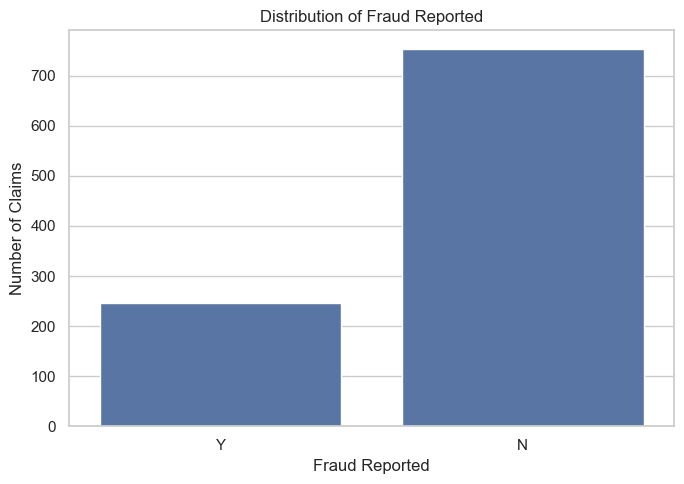

In [159]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="fraud_reported"
)

plt.title("Distribution of Fraud Reported")
plt.xlabel("Fraud Reported")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

## EDA Visualisations

In [160]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', '_c39']

Categorical columns:
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'fraud_reported']


### Numerical Feature Distributions

Histograms are used to understand the distribution of each numerical
variable.

These plots help identify:
- concentration of observations
- skewed distributions
- unusual values
- possible outliers
- the approximate range of each variable

The distributions will also help guide the preprocessing decisions
performed later.

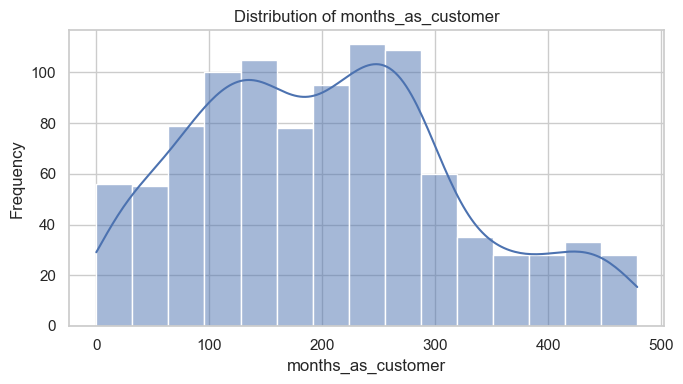

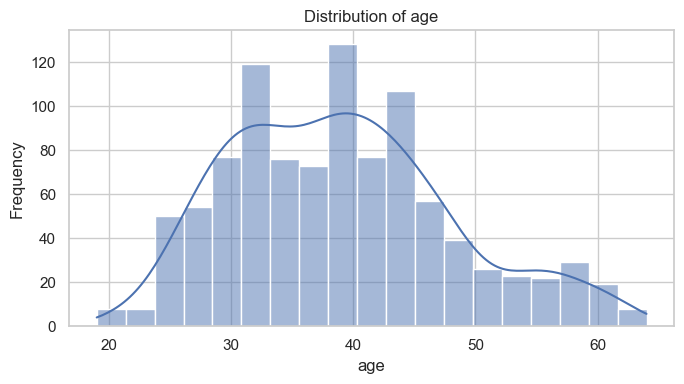

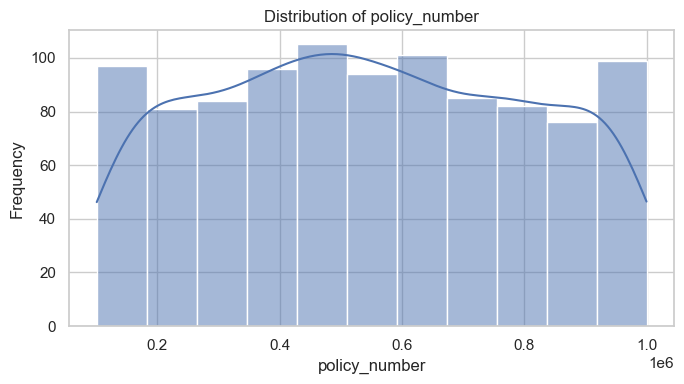

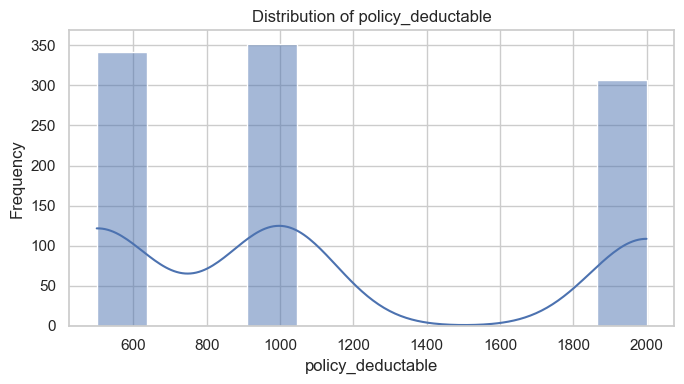

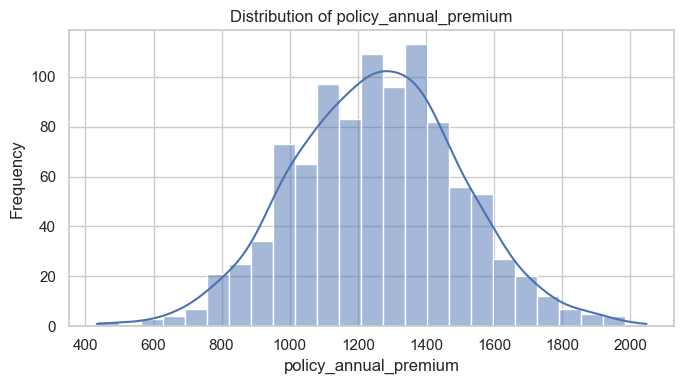

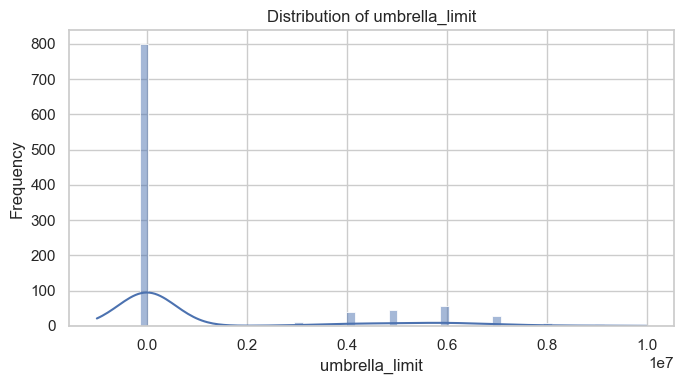

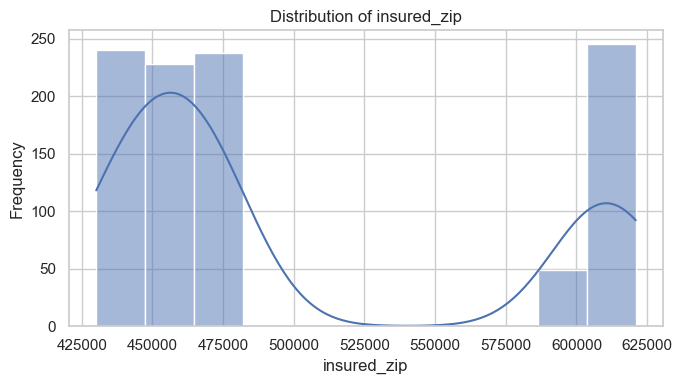

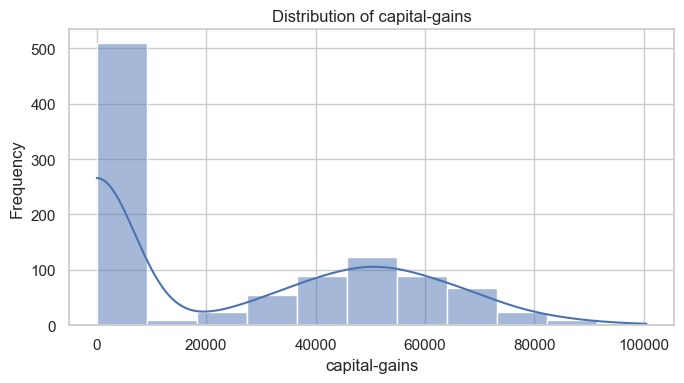

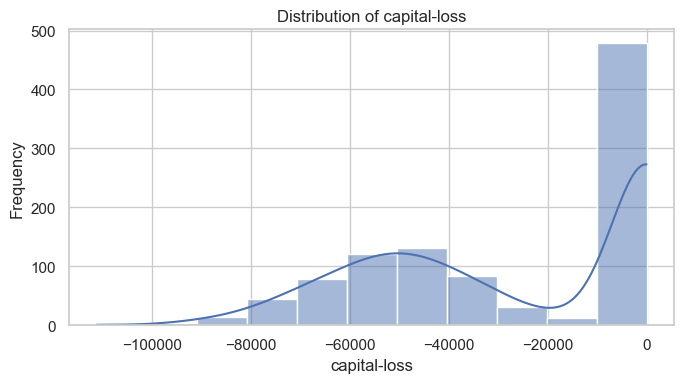

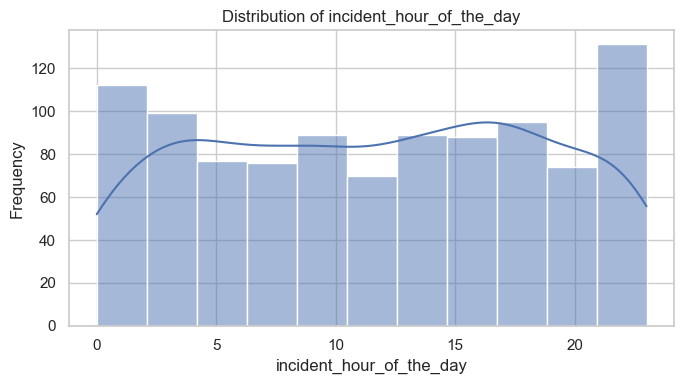

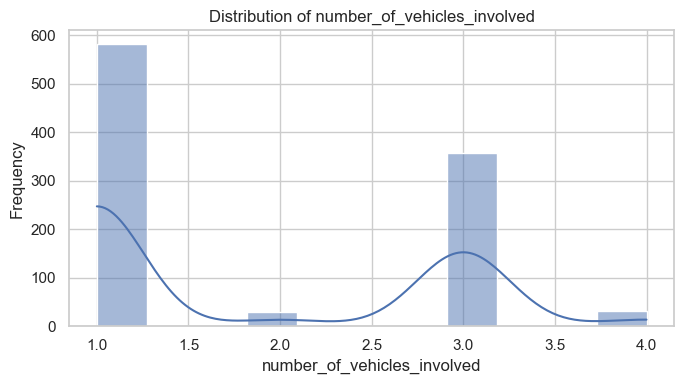

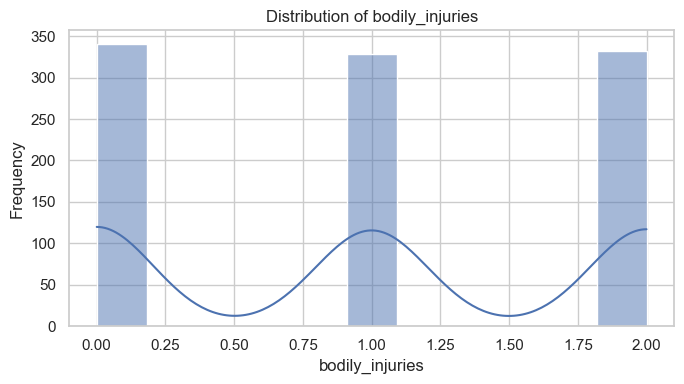

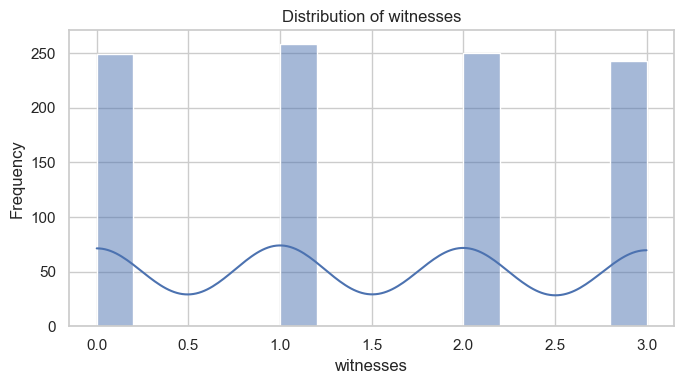

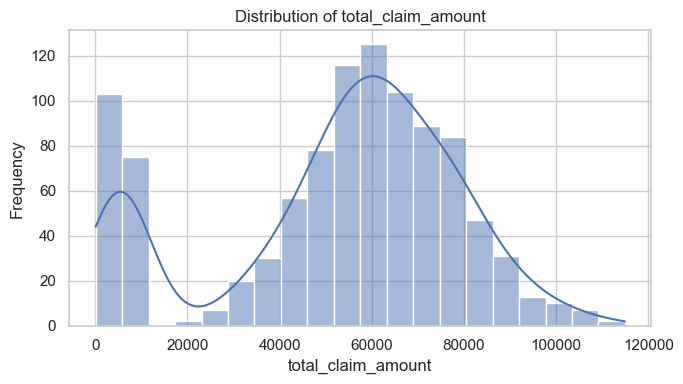

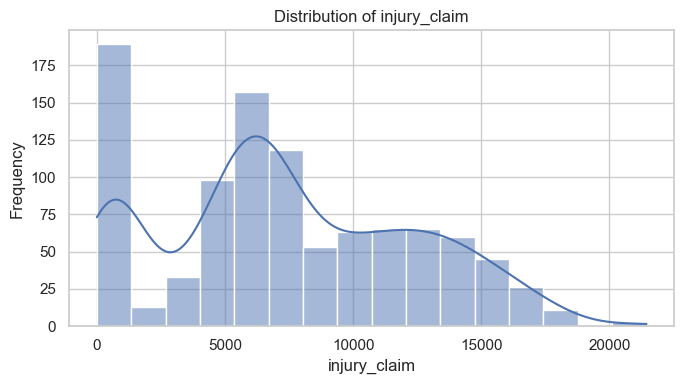

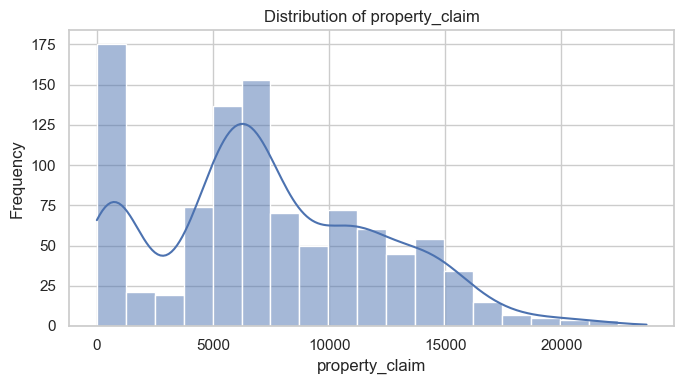

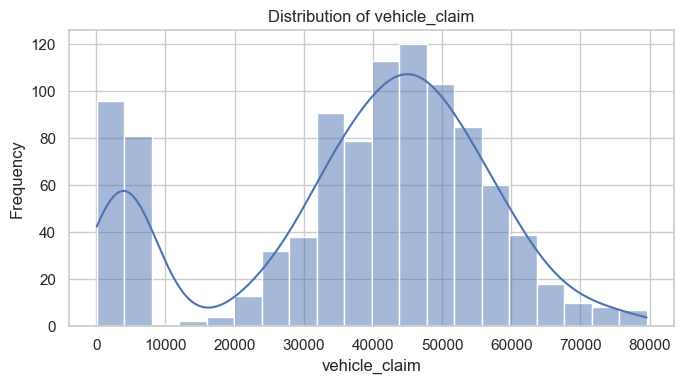

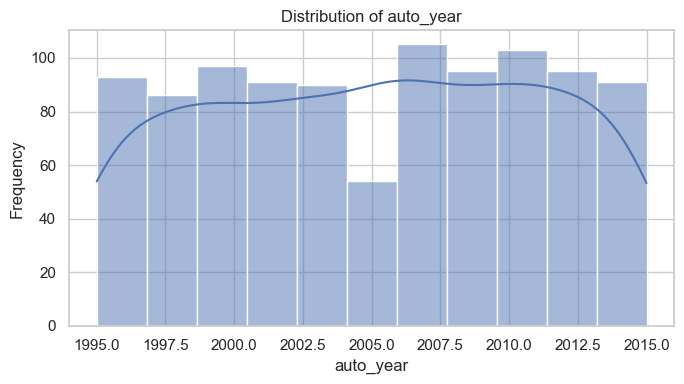

In [161]:
numeric_features = [
    col for col in numeric_columns
    if col not in ["_c39", "fraud_reported"]
]

for col in numeric_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Categorical Feature Distributions

Bar plots are used for categorical variables because they show how
frequently each category occurs.

For variables containing many unique categories, only the most frequent
categories are displayed so that the visualisation remains readable.
The complete category information is still retained in the dataset.
Plotting every category would produce an unreadable visualization.

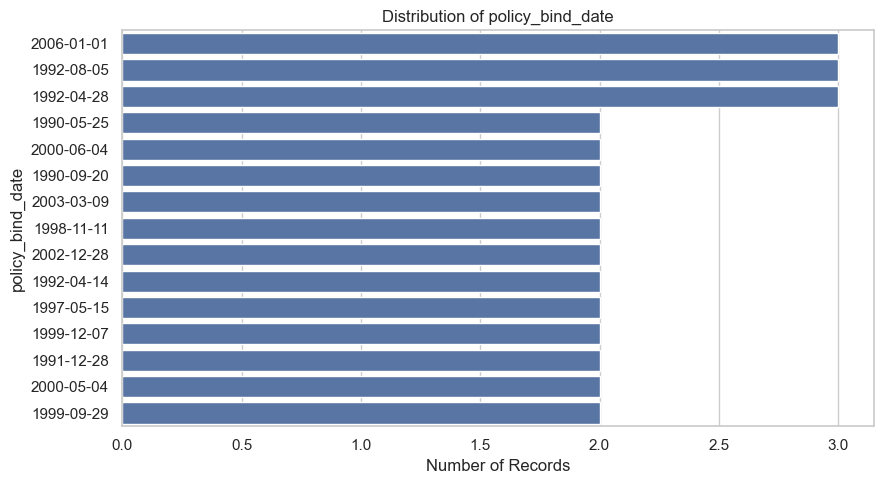

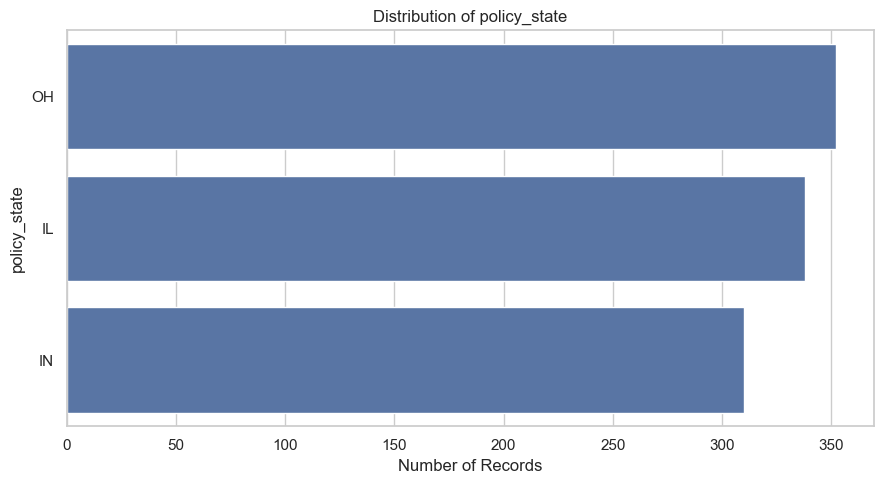

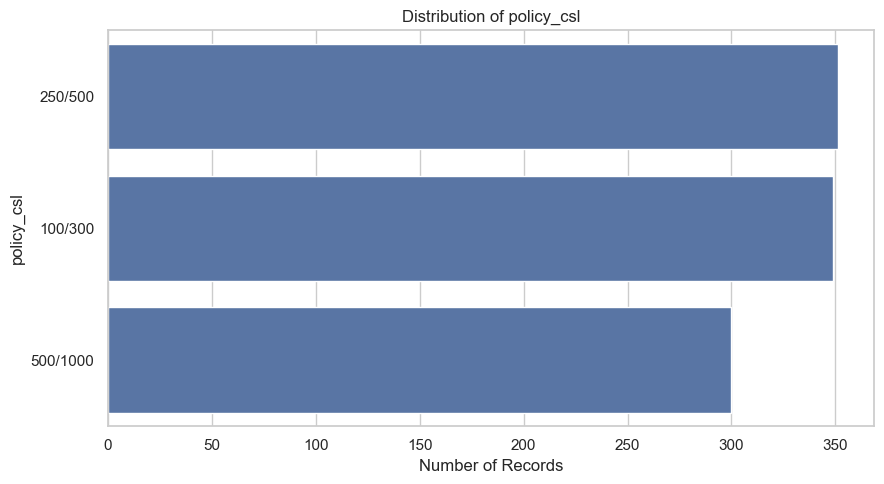

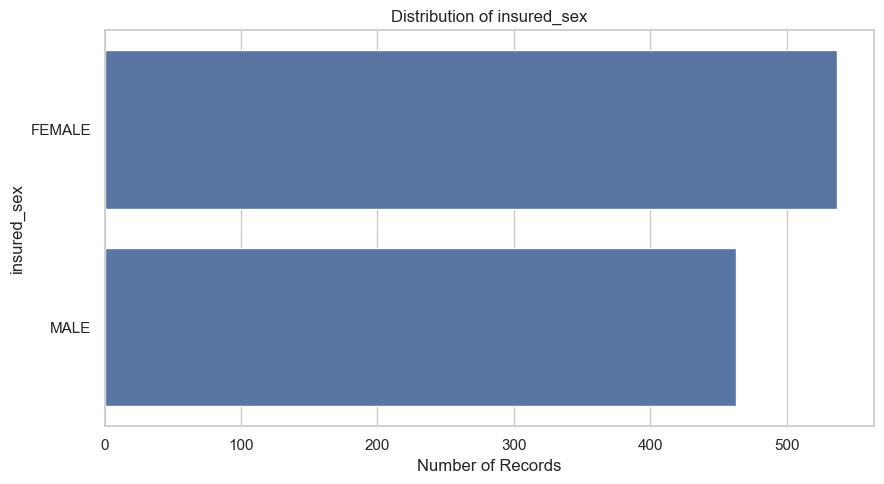

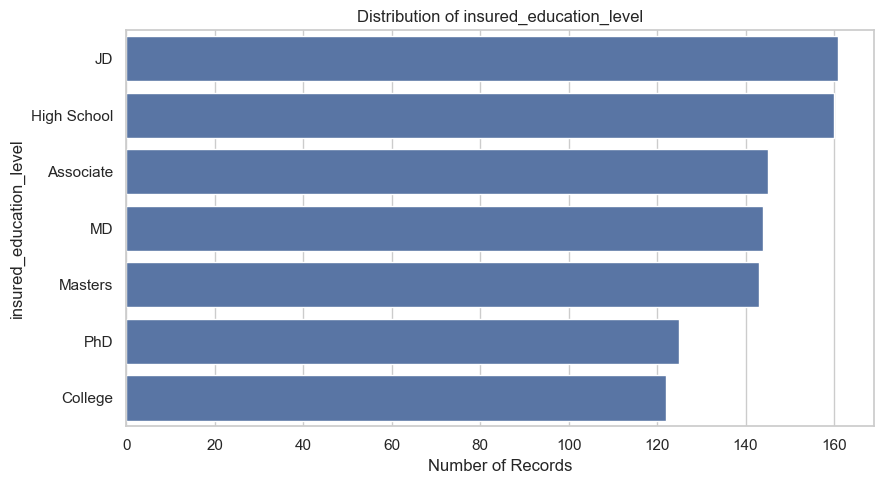

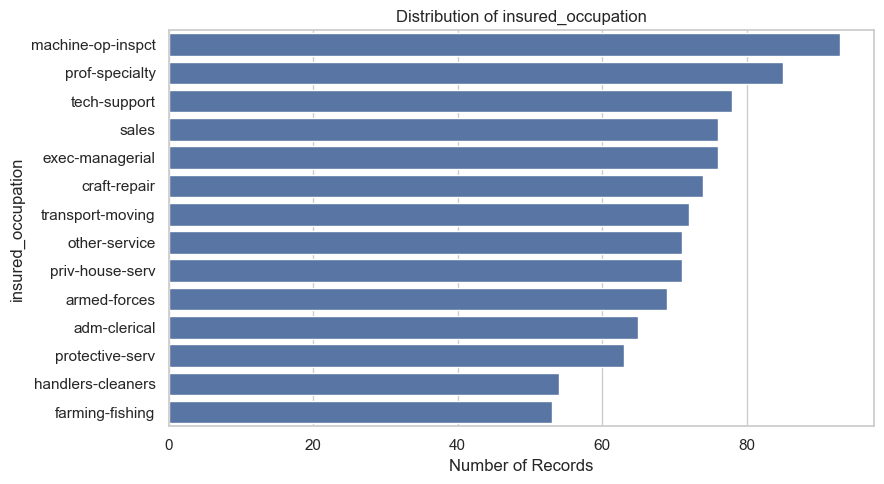

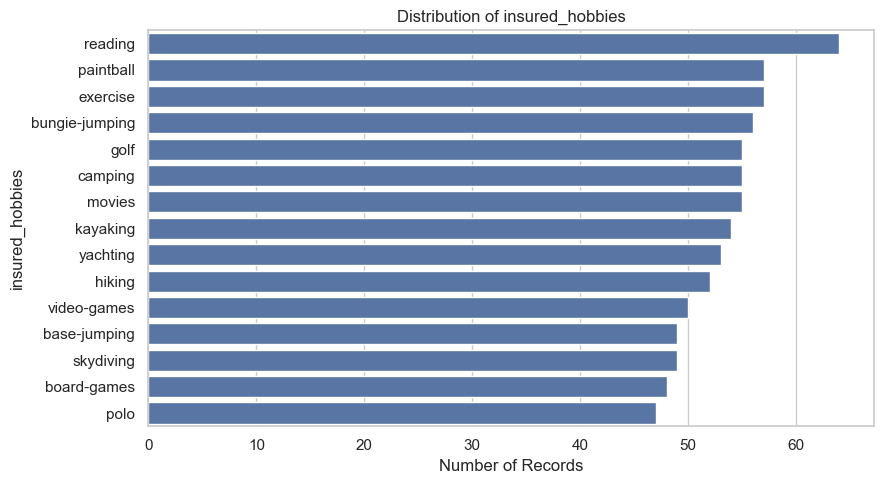

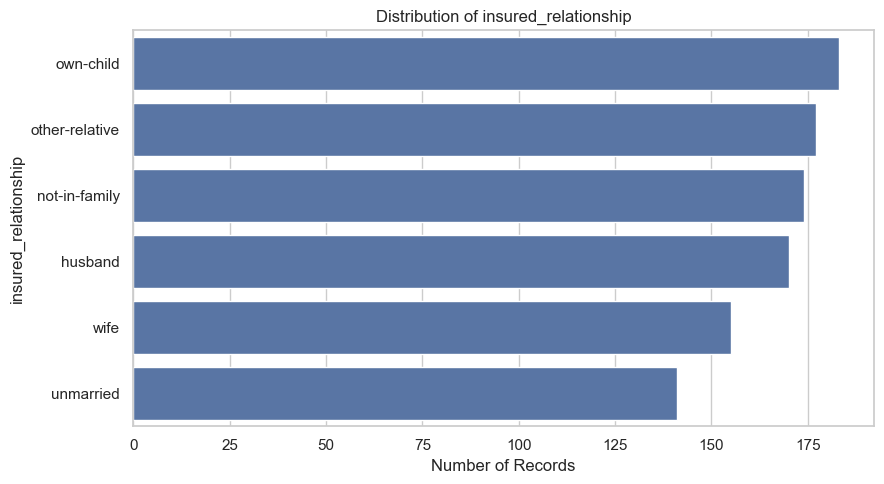

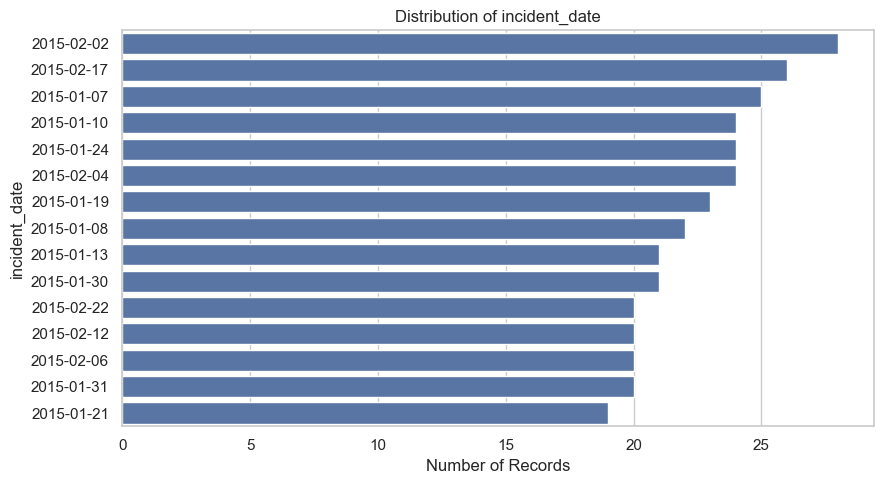

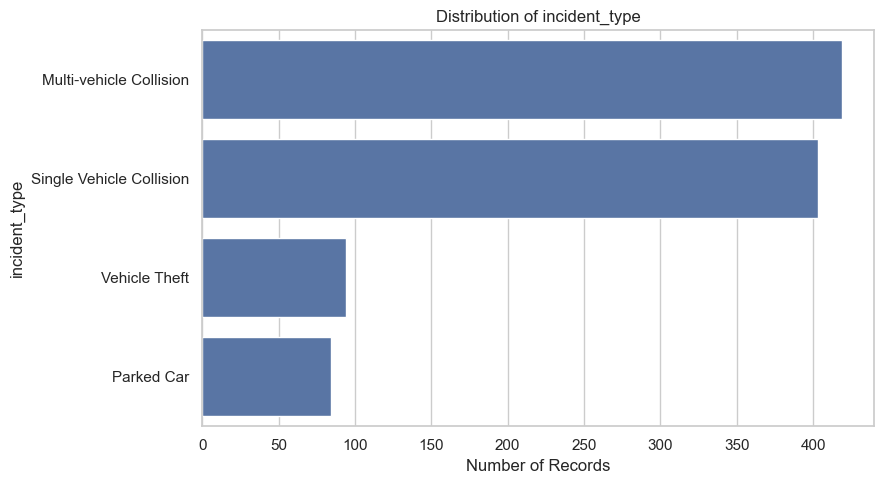

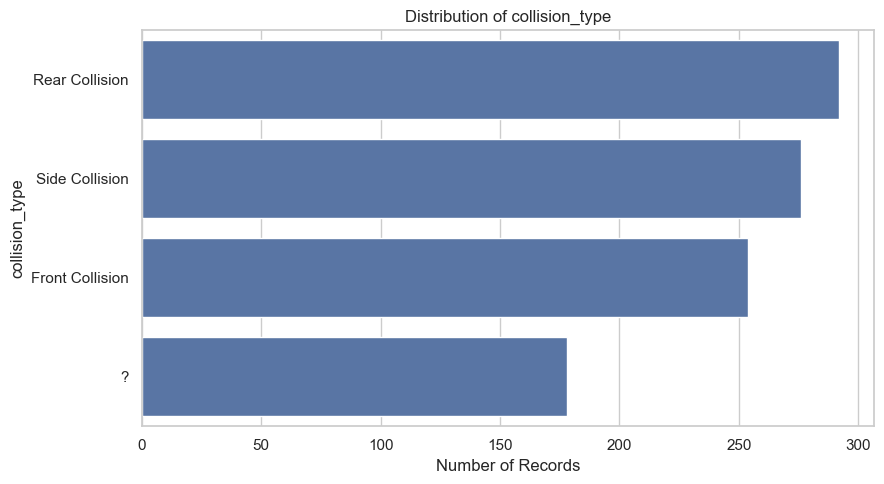

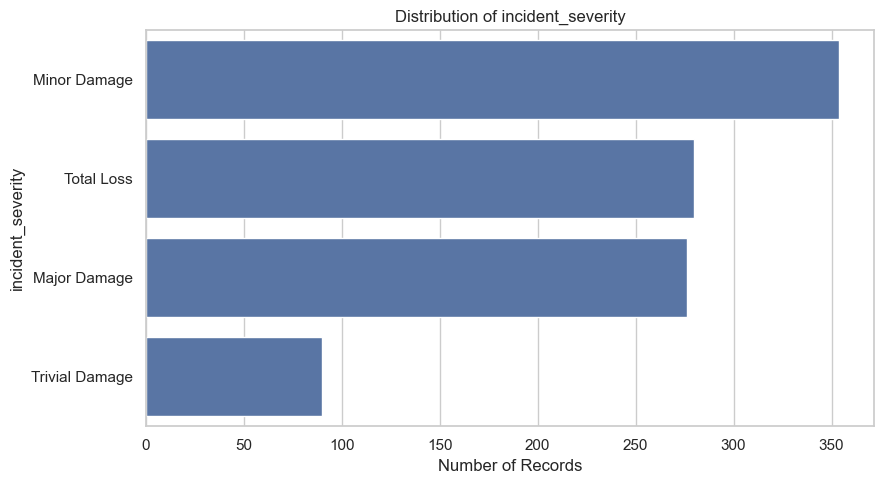

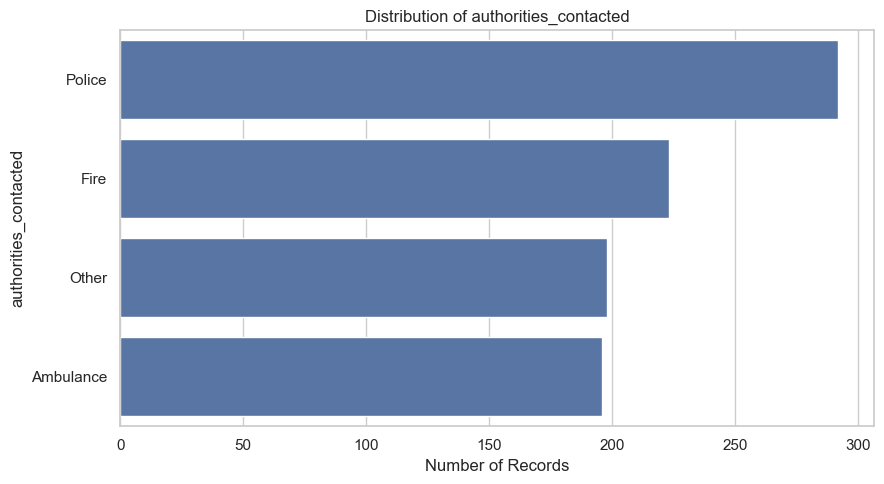

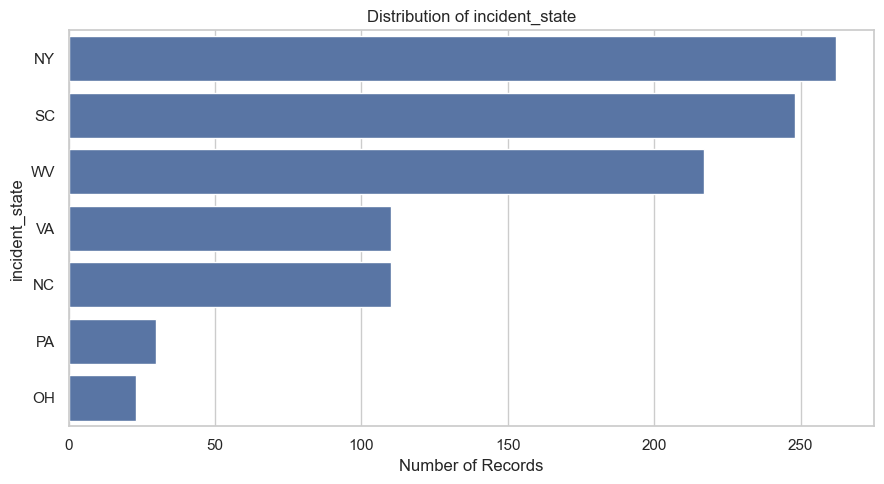

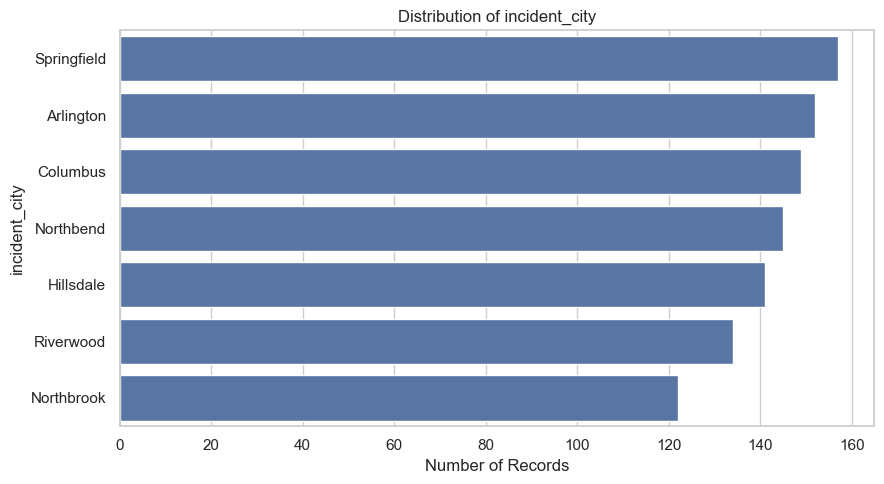

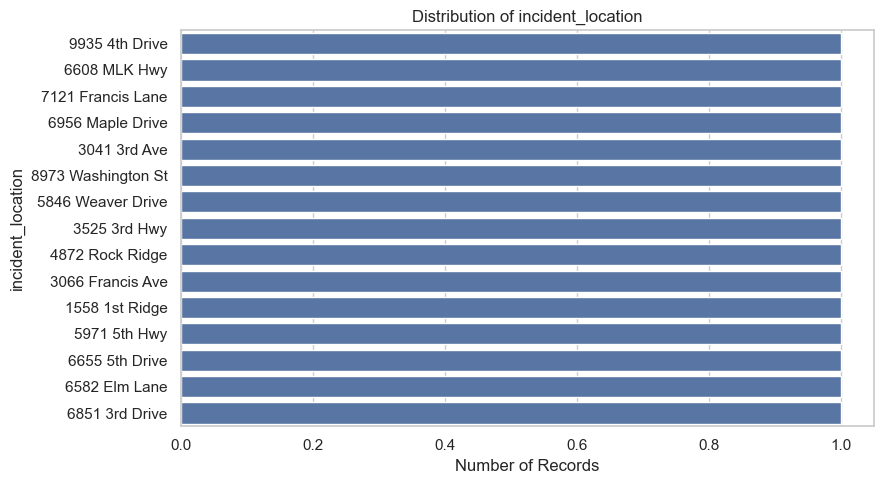

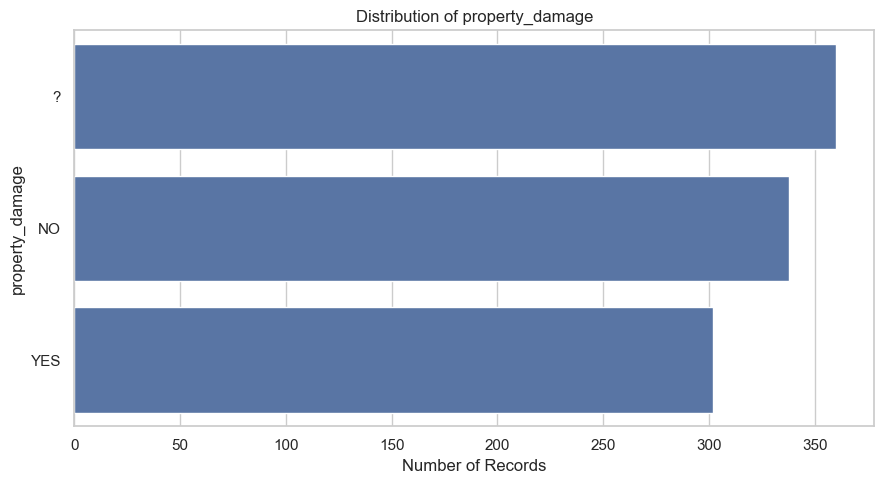

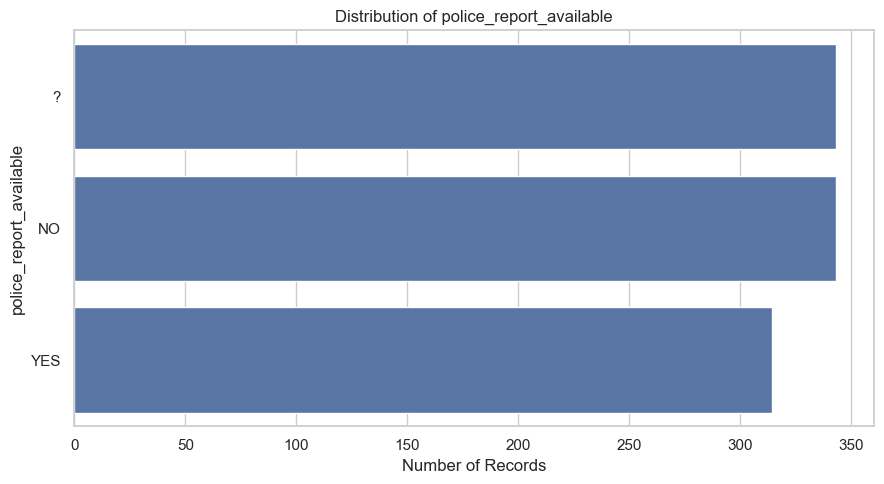

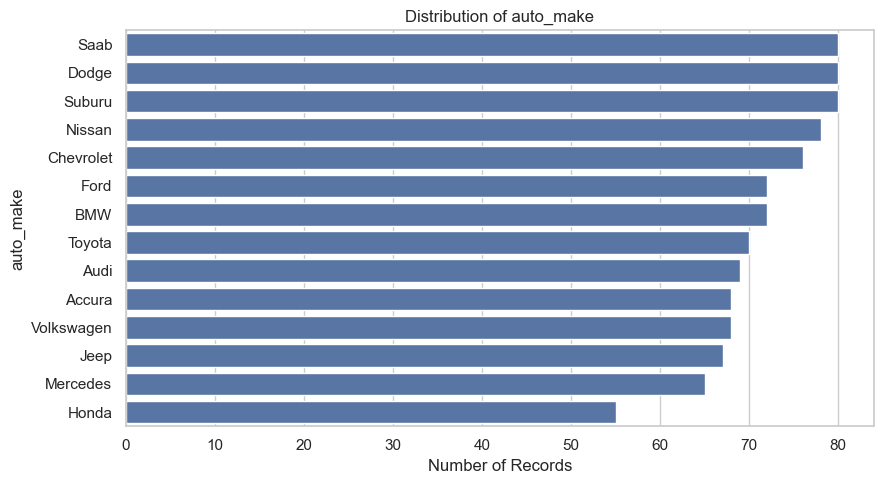

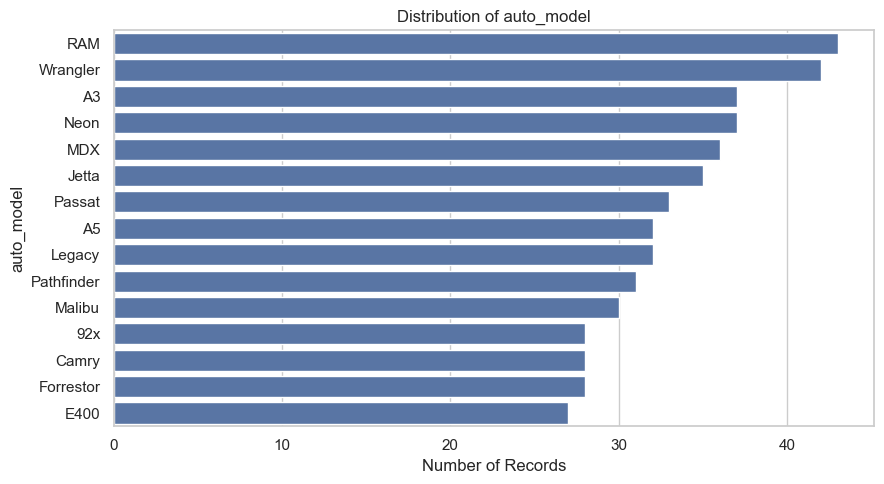

In [162]:
categorical_features = [
    col for col in categorical_columns
    if col != "fraud_reported"
]

for col in categorical_features:

    plt.figure(figsize=(9, 5))

    value_counts = df[col].value_counts()

    # Show all categories when there are relatively few
    if len(value_counts) <= 15:
        plot_data = value_counts
    else:
        plot_data = value_counts.head(15)

    sns.barplot(
        x=plot_data.values,
        y=plot_data.index
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel("Number of Records")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Correlation Heatmap

The correlation heatmap shows the pairwise linear correlation between
numerical variables.

Correlation values close to +1 indicate a strong positive relationship,
while values close to -1 indicate a strong negative relationship.
Values near 0 indicate a weak linear relationship.

The heatmap is useful for identifying groups of highly related numerical
features and potential redundancy before model training.

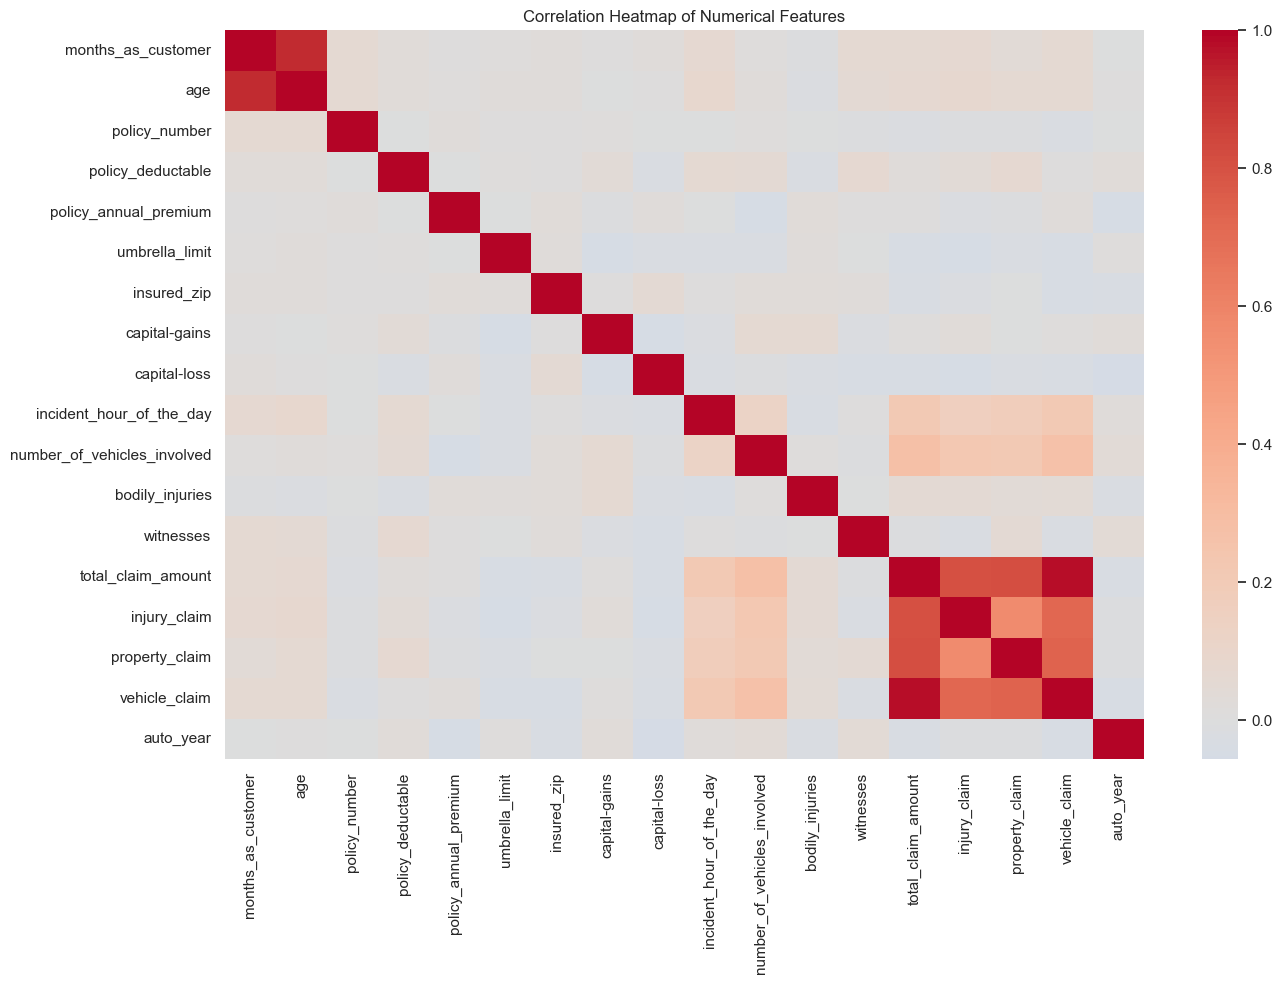

In [163]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Feature-target relationship — Scatter Plot 1

Since ```fraud_reported``` is categorical, we'll create a numerical representation specifically for visualization.

In [164]:
eda_df = df.copy()

eda_df["fraud_target"] = eda_df["fraud_reported"].map({
    "N": 0,
    "Y": 1
})

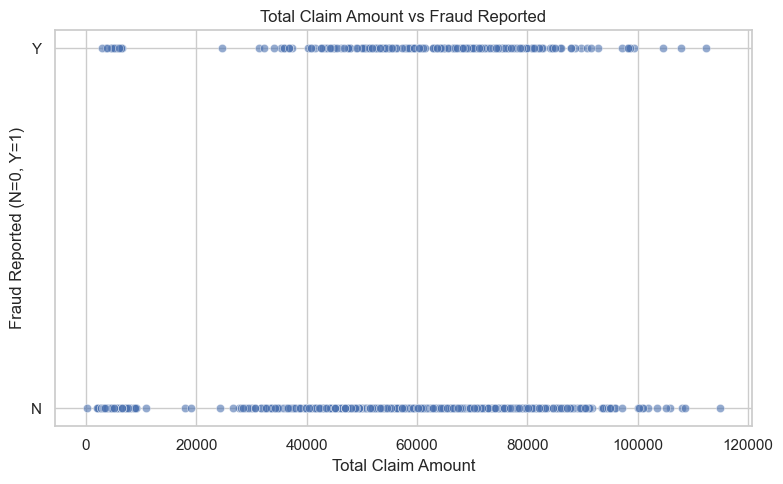

In [165]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_df,
    x="total_claim_amount",
    y="fraud_target",
    alpha=0.6
)

plt.title("Total Claim Amount vs Fraud Reported")
plt.xlabel("Total Claim Amount")
plt.ylabel("Fraud Reported (N=0, Y=1)")

plt.yticks([0, 1], ["N", "Y"])

plt.tight_layout()
plt.show()

### Observation – Total Claim Amount vs Fraud

This scatter plot is used to examine whether the distribution of total
claim amounts differs between fraudulent and non-fraudulent claims.

Because the target is categorical, `N` and `Y` are represented as 0 and 1
only for visualisation purposes.


### Feature-target relationship — Scatter Plot 2

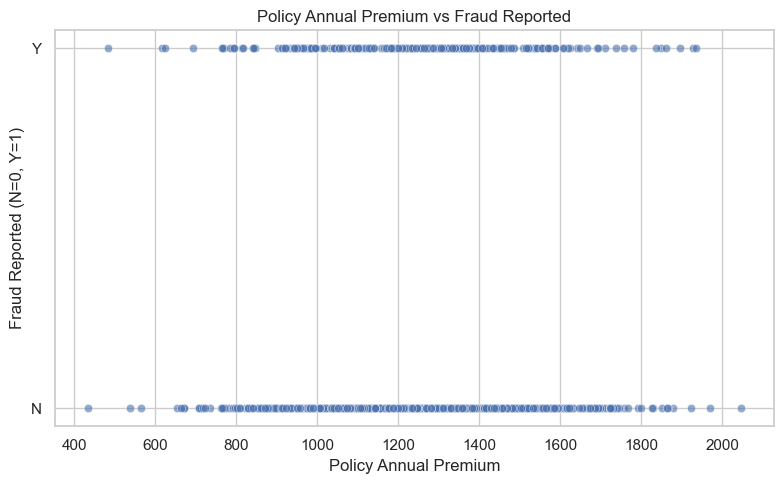

In [166]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_df,
    x="policy_annual_premium",
    y="fraud_target",
    alpha=0.6
)

plt.title("Policy Annual Premium vs Fraud Reported")
plt.xlabel("Policy Annual Premium")
plt.ylabel("Fraud Reported (N=0, Y=1)")

plt.yticks([0, 1], ["N", "Y"])

plt.tight_layout()
plt.show()

### Observation – Annual Premium vs Fraud

This plot examines whether annual premium values show different patterns
across the two fraud classes.

The purpose is exploratory: it helps determine whether this feature may
contain useful information for classification.

## EDA Summary

The exploratory analysis was performed to understand the structure,
quality, distributions, relationships, and target composition of the
insurance claims dataset.

The EDA focused on:

1. Numerical feature distributions to identify skewness and unusual values.
2. Categorical feature distributions to identify dominant and rare categories.
3. The target distribution to understand the class composition.
4. Correlation analysis to identify relationships among numerical variables.
5. Feature-target plots to identify variables that may provide useful
   information for fraud classification.

## Section B — Preprocessing & Feature Engineering

In [167]:
# check duplicates
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [168]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate handling:", df.shape)

Shape after duplicate handling: (1000, 40)


### Completely Empty Columns

Columns containing no observed values cannot provide predictive
information.

The `_c39` column contains only missing values, so it is removed from
the dataset.

In [169]:
empty_columns = [
    col for col in df.columns
    if df[col].isna().all()
]

print("Completely empty columns:", empty_columns)

df = df.drop(columns=empty_columns)

print("Shape after removing empty columns:", df.shape)

Completely empty columns: ['_c39']
Shape after removing empty columns: (1000, 39)


### Outlier Detection

The IQR method is used to identify potential outliers.

For each numerical feature:

IQR = Q3 − Q1

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are flagged as potential outliers.

An outlier is not automatically an error. Therefore, the objective is
not to blindly delete such observations, but to identify extreme values
and decide on an appropriate treatment.

In [170]:
numeric_for_outlier_check = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["policy_number", "insured_zip"]
]

outlier_summary = []

for col in numeric_for_outlier_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": count
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
))

,Feature,Lower Bound,Upper Bound,Outlier Count
4,umbrella_limit,0.00000,0.00000,202
3,policy_annual_premium,600.47625,1904.82625,9
13,property_claim,-5215.00000,20545.00000,6
1,age,14.00000,62.00000,4
11,total_claim_amount,-1357.50000,113762.50000,1
5,capital-gains,-76537.50000,127562.50000,0
2,policy_deductable,-1750.00000,4250.00000,0
0,months_as_customer,-125.00000,517.00000,0
7,incident_hour_of_the_day,-10.50000,33.50000,0
6,capital-loss,-128750.00000,77250.00000,0


### Date Processing

The original date columns are converted from text into datetime format.

Instead of directly providing raw date strings to machine learning models,
useful components such as year, month, and day of the week are extracted.

These numerical features can represent temporal patterns that may be
useful to a classification model.

The original date columns are then removed because machine learning
algorithms cannot directly use date strings as numerical inputs.

In [171]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"])
df["incident_date"] = pd.to_datetime(df["incident_date"])

df["policy_bind_year"] = df["policy_bind_date"].dt.year
df["policy_bind_month"] = df["policy_bind_date"].dt.month

df["incident_year"] = df["incident_date"].dt.year
df["incident_month"] = df["incident_date"].dt.month
df["incident_dayofweek"] = df["incident_date"].dt.dayofweek

df = df.drop(columns=["policy_bind_date", "incident_date"])

### Identifier and High-Cardinality Features

Some columns are primarily identifiers or contain extremely high
cardinality.

`policy_number` is a unique policy identifier, while `incident_location`
contains almost one unique value per record. Such variables can encourage
the model to learn record-specific patterns rather than generalizable
relationships.

These columns are therefore excluded from the modelling features.

In [172]:
identifier_columns = [
    "policy_number",
    "insured_zip",
    "incident_location"
]

df = df.drop(columns=identifier_columns)

print("Removed identifier/high-cardinality columns:", identifier_columns)

Removed identifier/high-cardinality columns: ['policy_number', 'insured_zip', 'incident_location']


## Feature Engineering

### Engineered Feature 1 – Claim-to-Premium Ratio

A new feature called `claim_premium_ratio` is created:

claim_premium_ratio =
total_claim_amount / policy_annual_premium

The ratio provides information about the size of the claim relative to
the policy's annual premium.

Two claims with the same absolute claim amount may represent different
situations depending on their corresponding premiums. Therefore, the
ratio may provide the classifier with additional information that is
not directly represented by either variable alone.

### Engineered Feature 2 – Vehicle Age

The `vehicle_age` feature is calculated using:

vehicle_age = incident_year − auto_year

Vehicle age may provide additional context about the vehicle involved
in the claim and may capture information that is less directly visible
when using the vehicle manufacturing year alone.

In [173]:
df["claim_premium_ratio"] = (
    df["total_claim_amount"] /
    df["policy_annual_premium"].replace(0, np.nan)
)

In [174]:
df["vehicle_age"] = (
    df["incident_year"] - df["auto_year"]
)

In [175]:
# separate X and y
X = df.drop(columns=["fraud_reported"])
y = df["fraud_reported"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 40)
Target shape: (1000,)


### Train/Test Split

The dataset is divided into 80% training data and 20% testing data.

A stratified split is used so that the proportion of fraud and non-fraud
classes is approximately preserved in both sets.

The test set is kept separate and will only be used for final model
evaluation.

`random_state=42` ensures that the same split can be reproduced.

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (800, 40)
Testing set: (200, 40)

Training target distribution:
fraud_reported
N    0.7525
Y    0.2475
Name: proportion, dtype: float64

Testing target distribution:
fraud_reported
N    0.755
Y    0.245
Name: proportion, dtype: float64


In [200]:
# identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'policy_bind_year', 'policy_bind_month', 'incident_year', 'incident_month', 'incident_dayofweek', 'claim_premium_ratio', 'vehicle_age']

Categorical features:
['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


## Preprocessing Strategy

#### Numerical variables
Missing numerical values are replaced using the median. Median imputation is less affected by extreme values than mean imputation.

The numerical features are then standardized using StandardScaler.

#### Categorical variables
Missing categorical values are replaced using the most frequent category.

Categorical variables are converted into numerical form using One-HotEncoding.

`handle_unknown="ignore"` ensures that an unseen category in the test set does not cause an error.

Most importantly, the preprocessing object is not fitted on the entire
dataset. It will be fitted only on the training data through the
classification pipelines. **This prevents data leakage.**

In [201]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Outlier Treatment Decision

Potential outliers were identified using the IQR method.

Extreme values were not automatically removed because an unusually high
claim amount, premium, or other numerical value may represent a genuine
insurance claim rather than an erroneous observation.

Removing such records could discard potentially important fraud cases.

Therefore, the observations are retained, while the numerical variables
are standardized during preprocessing. The outlier analysis is retained
as part of the data-quality audit.

### Testing the Preprocessing pipeline

In [202]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (800, 167)
Processed testing shape: (200, 167)


## Section D - Classification Track [Part A]

## 1. Logistic Regression

Logistic Regression is used as the baseline classification model.

Although its name contains "regression", it is commonly used for
classification problems. It estimates the probability that an observation
belongs to a particular class and then assigns the class based on the
predicted probability.

We use it as a baseline so that the performance of more complex
classification algorithms can later be compared against it.

In [203]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

Why max_iter=1000?

Logistic Regression uses an iterative optimization process to find the model parameters.

Sometimes the default number of iterations is not enough for a dataset after one-hot encoding, so we allow up to 1000 iterations.

This doesn't mean the model will necessarily use all 1000.

### Model Training

In [204]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [205]:
# Generate Predictions
y_pred_lr = logistic_model.predict(X_test)

print("Predictions generated successfully.")
print(y_pred_lr[:10])

Predictions generated successfully.
['N' 'Y' 'N' 'Y' 'N' 'N' 'N' 'Y' 'N' 'N']


In [206]:
y_prob_lr = logistic_model.predict_proba(X_test)

print(y_prob_lr[:5])

[[0.95614731 0.04385269]
 [0.17559383 0.82440617]
 [0.96804928 0.03195072]
 [0.30855182 0.69144818]
 [0.98433596 0.01566404]]


In [207]:
# Evaluate Logistic Regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Logistic Regression Results")
print("----------------------------")
print(f"Accuracy          : {accuracy_lr:.4f}")
print(f"Weighted Precision: {precision_lr:.4f}")
print(f"Weighted Recall   : {recall_lr:.4f}")
print(f"Weighted F1 Score : {f1_lr:.4f}")

Logistic Regression Results
----------------------------
Accuracy          : 0.7950
Weighted Precision: 0.7840
Weighted Recall   : 0.7950
Weighted F1 Score : 0.7876


### Classification Report

The classification report provides class-wise precision, recall, and
F1-score in addition to the overall accuracy.

Weighted averages are used for the project comparison because they take
the number of samples belonging to each class into account.

In [208]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           N       0.84      0.89      0.87       151
           Y       0.60      0.49      0.54        49

    accuracy                           0.80       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.78      0.80      0.79       200



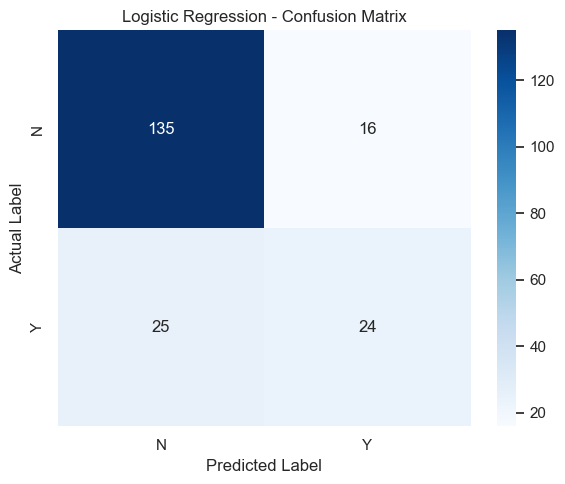

In [209]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["N", "Y"],
    yticklabels=["N", "Y"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

### Confusion Matrix Observation

The confusion matrix shows how Logistic Regression classified the two
target classes.

The diagonal cells represent correctly classified observations, while
the off-diagonal cells represent classification errors.

In particular, the false-negative count indicates how many claims
reported as fraud were classified as non-fraudulent.

In [210]:
classification_results = []

classification_results.append({
    "Algorithm": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1 Score": f1_lr
})

pd.DataFrame(classification_results)

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795,0.784031,0.795,0.787601


### Logistic Regression – Overall Observation

Logistic Regression achieved an accuracy of **0.795** and a weighted
F1-score of **0.787601** on the test set.

The confusion matrix shows that the model correctly classified **135 non-fraudulent** claims and **24 fraudulent** claims.

It incorrectly classified **16 non-fraudulent** claims as fraudulent (false
positives) and **25 fraudulent** claims as non-fraudulent (false negatives).

Overall, **159 out of 200** test samples were classified correctly,
corresponding to an accuracy of **79.5%.**

## 2. K-Nearest Neighbors (KNN)

KNN classifies a new data point by looking at the K closest training points and taking the majority class among them.
Because KNN depends on distances, feature scaling is important. Our existing StandardScaler handles this.

In [211]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Create and train the KNN model
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['N','Y']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['months_as_customer','age','policy_state',...,'incident_dayofweek', 'claim_premium_ratio','vehicle_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [212]:
# Make predictions

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)

In [213]:
# Evaluation Metrics

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(
    y_test, y_pred_knn, average="weighted"
)
recall_knn = recall_score(
    y_test, y_pred_knn, average="weighted"
)
f1_knn = f1_score(
    y_test, y_pred_knn, average="weighted"
)

print("KNN Accuracy :", accuracy_knn)
print("KNN Precision:", precision_knn)
print("KNN Recall   :", recall_knn)
print("KNN F1 Score :", f1_knn)

KNN Accuracy : 0.72
KNN Precision: 0.6653303856546303
KNN Recall   : 0.72
KNN F1 Score : 0.6805420054200542


In [214]:
# Classification Report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           N       0.77      0.90      0.83       151
           Y       0.35      0.16      0.22        49

    accuracy                           0.72       200
   macro avg       0.56      0.53      0.53       200
weighted avg       0.67      0.72      0.68       200



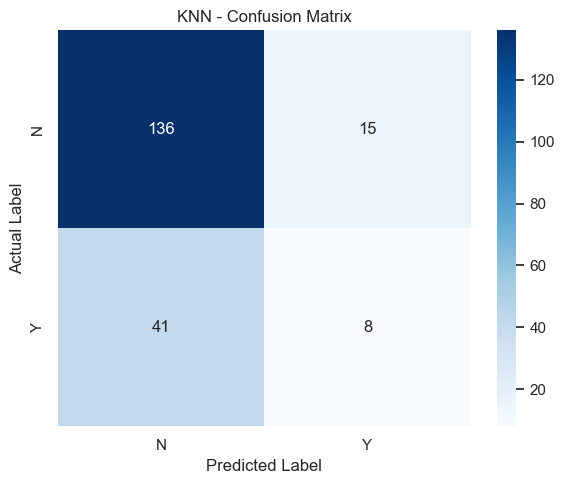

In [215]:
# Confusion Matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["N", "Y"],
    yticklabels=["N", "Y"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [216]:
# Adding KNN to the comparison table

classification_results.append({
    "Algorithm": "KNN",
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1 Score": f1_knn
})

pd.DataFrame(classification_results)

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795,0.784031,0.795,0.787601
1,KNN,0.720,0.665330,0.720,0.680542


## 3. Gaussian Naive Bayes

It calculates the probability that a claim belongs to each class (N or Y) based on its features, then chooses the more probable class.

One important difference from KNN: GaussianNB expects numerical input, so we need to use our preprocessing pipeline to convert the categorical features into numerical values.

In [217]:
from sklearn.naive_bayes import GaussianNB

# create the model
nb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

nb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U1](2,)","['N','Y']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](40,)","['months_as_customer','age','policy_state',...,'incident_dayofweek', 'claim_premium_ratio','vehicle_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,40
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spe

In [218]:
# predictions
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)

In [219]:
# calculate metrics

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(
    y_test, y_pred_nb, average="weighted"
)
recall_nb = recall_score(
    y_test, y_pred_nb, average="weighted"
)
f1_nb = f1_score(
    y_test, y_pred_nb, average="weighted"
)

print("Gaussian Naive Bayes Accuracy :", accuracy_nb)
print("Gaussian Naive Bayes Precision:", precision_nb)
print("Gaussian Naive Bayes Recall   :", recall_nb)
print("Gaussian Naive Bayes F1 Score :", f1_nb)

Gaussian Naive Bayes Accuracy : 0.625
Gaussian Naive Bayes Precision: 0.6992708333333333
Gaussian Naive Bayes Recall   : 0.625
Gaussian Naive Bayes F1 Score : 0.6486098000514889


In [220]:
# classification report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           N       0.82      0.65      0.72       151
           Y       0.34      0.55      0.42        49

    accuracy                           0.62       200
   macro avg       0.58      0.60      0.57       200
weighted avg       0.70      0.62      0.65       200



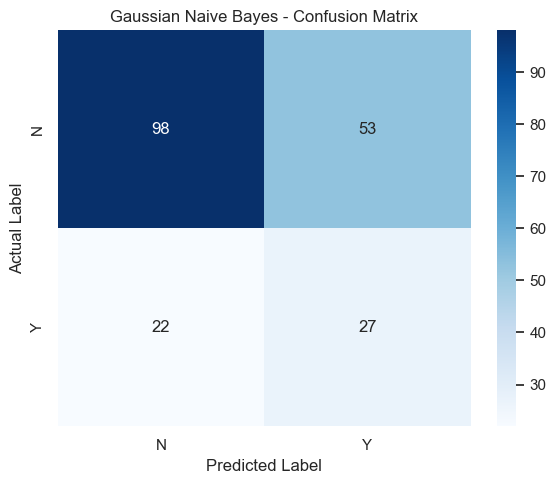

In [221]:
# confusion matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["N", "Y"],
    yticklabels=["N", "Y"]
)

plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [222]:
# comparison table

classification_results.append({
    "Algorithm": "Gaussian Naive Bayes",
    "Accuracy": accuracy_nb,
    "Precision": precision_nb,
    "Recall": recall_nb,
    "F1 Score": f1_nb
})

pd.DataFrame(classification_results)

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795,0.784031,0.795,0.787601
1,KNN,0.720,0.665330,0.720,0.680542
2,Gaussian Naive Bayes,0.625,0.699271,0.625,0.648610
